In [61]:
# Parquet dosyasından veriyi alıp pandas'a aktarma
import pandas as pd
import pyarrow as pq
import pyarrow.parquet as pa

table = pa.read_table('../data/raw/nrel_data_2021_2023_Colorado.parquet')

df = table.to_pandas()

print(df)

                     Year  Month  Day  Hour  Minute  GHI  DHI  DNI  \
datetime                                                             
2021-01-01 00:00:00  2021      1    1     0       0    0    0    0   
2021-01-01 00:30:00  2021      1    1     0      30    0    0    0   
2021-01-01 01:00:00  2021      1    1     1       0    0    0    0   
2021-01-01 01:30:00  2021      1    1     1      30    0    0    0   
2021-01-01 02:00:00  2021      1    1     2       0    0    0    0   
...                   ...    ...  ...   ...     ...  ...  ...  ...   
2023-12-31 21:30:00  2023     12   31    21      30    0    0    0   
2023-12-31 22:00:00  2023     12   31    22       0    0    0    0   
2023-12-31 22:30:00  2023     12   31    22      30    0    0    0   
2023-12-31 23:00:00  2023     12   31    23       0    0    0    0   
2023-12-31 23:30:00  2023     12   31    23      30    0    0    0   

                     Wind Speed  Temperature  Cloud Type  Dew Point  \
datetime          

In [62]:
# Gece Körlüğü Filtrelemesi
# Geceleri güneş paneli üretim yapmayacağı için (GHI = 0) bunları modelde tutmak başarı oranının (RMSE) "sahte" şekilde 
# yüksek çıkmasına neden olur.
night_mask = (df['Solar Zenith Angle'] > 90) | (df['GHI'] == 0)
day_df = df.loc[~night_mask].reset_index(drop=True)
print(day_df.head())
print(f"Eski satır: {len(df)}, Gündüz satır: {len(day_df)}")

   Year  Month  Day  Hour  Minute  GHI  DHI  DNI  Wind Speed  Temperature  \
0  2021      1    1     7      30    9    9    1         1.6         -5.0   
1  2021      1    1     8       0   70   41  310         1.8         -3.8   
2  2021      1    1     8      30  105   75  177         2.0         -2.7   
3  2021      1    1     9       0  140  129   45         2.2         -1.6   
4  2021      1    1     9      30  184  179   15         2.0         -0.7   

   Cloud Type  Dew Point  Relative Humidity  Solar Zenith Angle  \
0           8       -8.7          75.529999           89.129997   
1           0       -7.9          73.199997           84.540001   
2           4       -7.9          67.440002           80.080002   
3           4       -6.8          67.480003           75.949997   
4           4       -6.8          63.180000           72.239998   

   Requested Year  
0            2021  
1            2021  
2            2021  
3            2021  
4            2021  
Eski satır: 52

In [63]:
# Günlük Gürültü Skorunu Bulma (Daily Volatility)
# Her günü GHI bazında ortalama ve standart sapmasını bulan tablo oluşturma
day_df['datetime'] = pd.to_datetime(
    day_df[['Year','Month','Day','Hour','Minute']].rename(columns={'Year':'year',
                                                                  'Month':'month',
                                                                  'Day':'day',
                                                                  'Hour': 'hour',
                                                                  'Minute':'minute'}))

day_df = day_df.set_index('datetime')

daily_table = day_df.resample('D')['GHI'].agg(['mean', 'std'])
print(daily_table)

                  mean         std
datetime                          
2021-01-01  271.526316  169.584908
2021-01-02  304.842105  191.342991
2021-01-03  226.578947  190.342474
2021-01-04  308.157895  178.394775
2021-01-05  260.157895  145.933494
...                ...         ...
2023-12-27  278.736842  175.354511
2023-12-28  302.842105  169.192613
2023-12-29  303.210526  168.930485
2023-12-30  299.947368  167.132174
2023-12-31  218.947368  122.848359

[1095 rows x 2 columns]


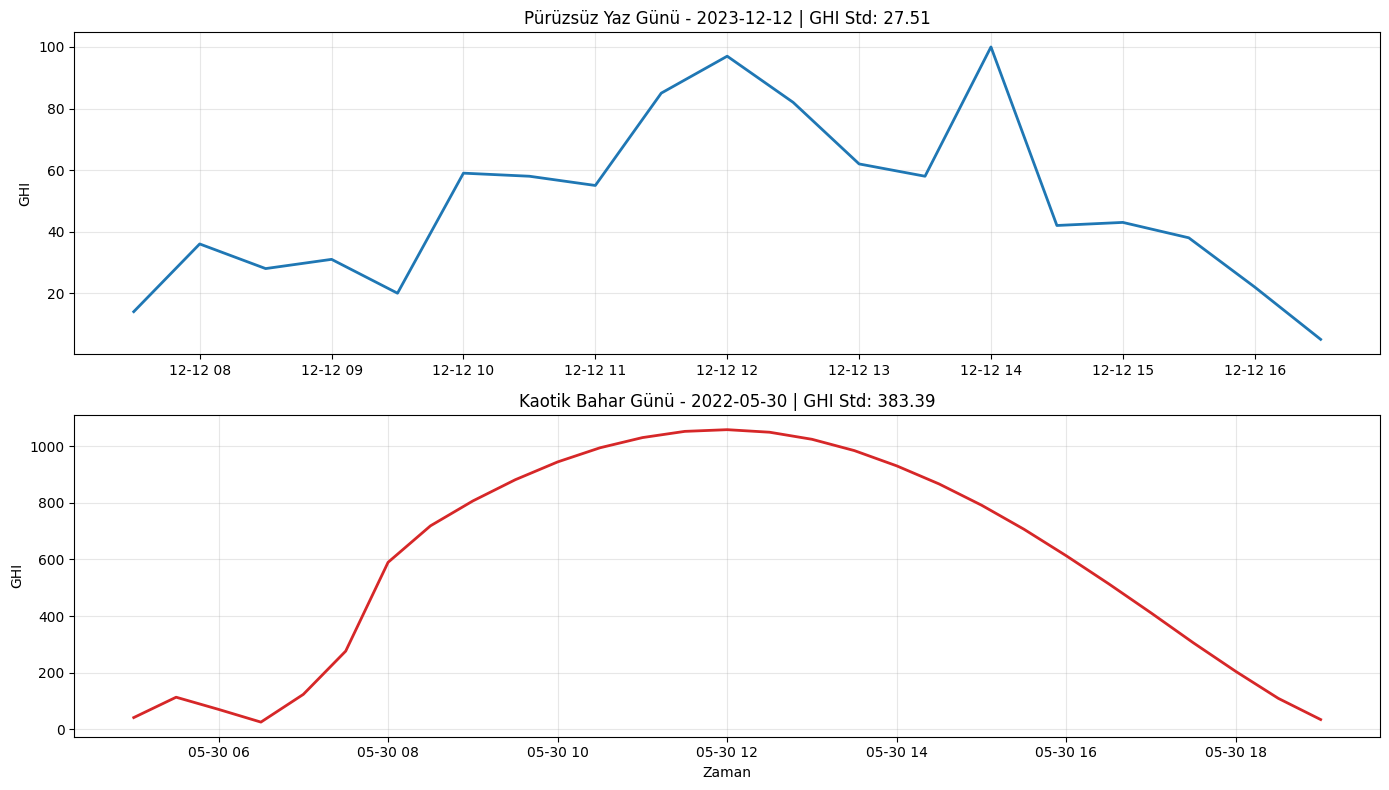

In [64]:
# En düşük çıkan yaz günü ile en yüksek çıkan bahar günün GHI karşılaştırması
import matplotlib.pyplot as plt

smooth_day = daily_table['std'].idxmin()
chaotic_day = daily_table['std'].idxmax()

smooth_ghi = day_df.loc[str(smooth_day.date())]['GHI']
chaotic_ghi = day_df.loc[str(chaotic_day.date())]['GHI']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(smooth_ghi.index, smooth_ghi.values, color='tab:blue', linewidth=2)
axes[0].set_title(f"Pürüzsüz Yaz Günü - {smooth_day.date()} | GHI Std: {daily_table.loc[smooth_day, 'std']:.2f}")
axes[0].set_ylabel("GHI")
axes[0].grid(True, alpha=0.3)

axes[1].plot(chaotic_ghi.index, chaotic_ghi.values, color='tab:red', linewidth=2)
axes[1].set_title(f"Kaotik Bahar Günü - {chaotic_day.date()} | GHI Std: {daily_table.loc[chaotic_day, 'std']:.2f}")
axes[1].set_xlabel("Zaman")
axes[1].set_ylabel("GHI")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()